# Implementing Logistic Regression with numpy

In this problem, you will need to write python codes and build logistic regression classifiers on breast cancer dataset to predict whether the cancer is malignant or benign on the patients. The dataset contains 569 samples and 30 features. You may refer to https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic) for more information about the dataset.

Your implementations should include:
- Load data, clean data and partition them into training and testing data.
- Build logistic regression and L2-regularized logistic regression models.
- Implement three gradient descent algorithms for each model: Batch Gradient Descent (GD), Mini-Batch Gradient Descent (MB-SGD) and Stochastic Gradient Descent (SGD).
- Compare the loss curve of three gradient descent algorithms (GD/MB-SGD/SGD).
- Compare logistic regression and regularized version in terms of training and testing error.
- Try to tune different parameters (regularization parameter, learning rate, etc.) to see their effects.

You could use sklearn or any other packages to load and process the data, but you can not directly use the package to train the model.


### Name: Mandar Sanju Bavdane


#### For this assignment, you will build 6 models. You need to train Logistic Regression/Regularized Logistic Regression each with Batch Gradient Descent, Stochastic Gradient Descent and Mini Batch Gradient Descent. Also you should plot their objective values versus epochs and compare their training and testing accuracies. You will need to tune the parameters a little bit to obtain reasonable results.

#### You do not have to follow the following procedure. You may implement your own functions and methods, but you need to show your results and plots.

In [1]:
# Load Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split


# 1. Data processing

- Download the Breast Cancer dataset from canvas or from https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+(diagnostic)
- Load the data.
- Preprocess the data.

## 1.1. Load the data

In [2]:
# The sklearn copy of the Wisconsin Diagnostic Breast Cancer dataset has the same
# 569 samples and 30 predictive features described in the assignment.
# It is used only for loading the data; the model itself is implemented with NumPy.
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# sklearn encodes malignant=0 and benign=1.  We convert to the assignment's
# {-1, +1} convention in the cleaning cell below.
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 1.2 Examine and clean data

In [3]:
# Some columns may not be useful for the model (For example, the first column contains ID number which may be irrelavant). 
# You need to get rid of the ID number feature.
# Also you should transform target labels in the second column from 'B' and 'M' to 1 and -1.

# The sklearn loader does not include the original ID column; its 30 feature
# columns are already the predictive variables.  Convert the target to the
# assignment convention: benign -> +1, malignant -> -1.
x = df.drop(columns=["target"]).copy()
y = df["target"].map({0: -1, 1: 1}).astype(int).to_numpy().reshape(-1, 1)

print("x shape =", x.shape)
print("y shape =", y.shape)
print("class counts =", pd.Series(y.ravel()).value_counts().to_dict())


x shape = (569, 30)
y shape = (569, 1)
class counts = {1: 357, -1: 212}


## 1.3. Partition to training and testing sets

In [4]:
# You can partition using 80% training data and 20% testing data. It is a commonly used ratio in machinel learning.
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)


## 1.4. Feature scaling

Use the standardization to trainsform both training and test features

In [5]:
# Standardization
import numpy

# calculate mu and sig using the training set
d = x_train.shape[1]
mu = numpy.mean(x_train.values, axis=0).reshape(1, d)
sig = numpy.std(x_train.values, axis=0).reshape(1, d)

# transform the training features
x_train = (x_train - mu) / (sig + 1E-6)

# transform the test features
x_test = (x_test - mu) / (sig + 1E-6)

print('test mean = ')
print(numpy.mean(x_test, axis=0))

print('test std = ')
print(numpy.std(x_test, axis=0))

test mean = 
mean radius                0.085785
mean texture               0.047963
mean perimeter             0.085170
mean area                  0.091955
mean smoothness            0.071599
mean compactness           0.044072
mean concavity            -0.024083
mean concave points        0.073835
mean symmetry              0.096790
mean fractal dimension    -0.015471
radius error               0.115674
texture error             -0.016400
perimeter error            0.110162
area error                 0.130811
smoothness error          -0.067993
compactness error         -0.016191
concavity error           -0.101685
concave points error       0.097981
symmetry error            -0.134843
fractal dimension error   -0.004276
worst radius               0.096334
worst texture              0.024020
worst perimeter            0.095722
worst area                 0.104435
worst smoothness           0.008790
worst compactness         -0.001985
worst concavity           -0.101576
worst concave p

# 2.  Logistic Regression Model

The objective function is $Q (w; X, y) = \frac{1}{n} \sum_{i=1}^n \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $.

When $\lambda = 0$, the model is a regular logistric regression and when $\lambda > 0$, it essentially becomes a regularized logistric regression.

In [6]:
# Calculate the objective function value, or loss
# Inputs:
#     w: weight: d-by-1 vector
#     x: data: n-by-d matrix
#     y: label: n-by-1 vector
#     lam: regularization parameter: scalar
# Return:
#     objective function value, or loss (scalar)
def objective(w, x, y, lam):
    # y is in {-1,+1}; the per-example logistic loss is
    # log(1 + exp(-y * x^T w)).  logaddexp evaluates this stably.
    margin = y * (x @ w)
    loss = np.mean(np.logaddexp(0.0, -margin))
    reg = (lam / 2.0) * np.sum(w ** 2)
    return float(loss + reg)


# 3. Numerical optimization

## 3.1. Gradient descent


The gradient at $w$ for regularized logistic regression is  $g = - \frac{1}{n} \sum_{i=1}^n \frac{y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$

In [7]:
# Calculate the gradient
# Inputs:
#     w: weight: d-by-1 matrix
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: regularization parameter: scalar
# Return:
#     g: gradient: d-by-1 matrix

def gradient(w, x, y, lam):
    margin = y * (x @ w)

    # Compute sigmoid(-margin) without forming exp(large positive values).
    sigmoid_neg_margin = np.empty_like(margin, dtype=float)
    nonnegative = margin >= 0
    sigmoid_neg_margin[nonnegative] = (
        np.exp(-margin[nonnegative]) /
        (1.0 + np.exp(-margin[nonnegative]))
    )
    sigmoid_neg_margin[~nonnegative] = (
        1.0 / (1.0 + np.exp(margin[~nonnegative]))
    )

    g = -(x.T @ (y * sigmoid_neg_margin)) / x.shape[0] + lam * w
    return g


In [8]:
# Gradient descent for solving logistic regression
# You will need to do iterative process (loops) to obtain optimal weights in this function

# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 vector, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     w: weights: d-by-1 vector, the solution
#     objvals: a record of each epoch's objective value

def gradient_descent(x, y, lam, learning_rate, w, max_epoch=100):
    objvals = []

    for _ in range(max_epoch):
        g = gradient(w, x, y, lam)
        w = w - learning_rate * g
        objvals.append(objective(w, x, y, lam))

    return w, objvals


Use gradient_descent function to obtain your optimal weights and a list of objective values over each epoch.

In [9]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

w0 = np.zeros((x_train.shape[1], 1))
w_gd, obj_gd = gradient_descent(
    x_train.to_numpy(), y_train, lam=0.0, learning_rate=0.1, w=w0.copy(), max_epoch=100
)


In [10]:
# Train regularized logistric regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

lambda_reg = 0.01
w_gd_reg, obj_gd_reg = gradient_descent(
    x_train.to_numpy(), y_train, lam=lambda_reg, learning_rate=0.1,
    w=w0.copy(), max_epoch=100
)


## 3.2. Stochastic gradient descent (SGD)

Define new objective function $Q_i (w) = \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $. 

The stochastic gradient at $w$ is $g_i = \frac{\partial Q_i }{ \partial w} = -\frac{y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$.

You may need to implement a new function to calculate the new objective function and gradients.

In [11]:
# Calculate the objective Q_i and the gradient of Q_i
# Inputs:
#     w: weights: d-by-1 matrix
#     xi: data: 1-by-d matrix
#     yi: label: scalar
#     lam: scalar, the regularization parameter
# Return:
#     obj: scalar, the objective Q_i
#     g: d-by-1 matrix, gradient of Q_i

def stochastic_objective_gradient(w, xi, yi, lam):
    # Keep xi as a row vector so the returned gradient remains d-by-1.
    yi = float(np.asarray(yi).reshape(-1)[0])
    margin = yi * float((xi @ w).reshape(-1)[0])

    obj = float(np.logaddexp(0.0, -margin) + (lam / 2.0) * np.sum(w ** 2))

    # sigmoid(-margin), evaluated stably.
    if margin >= 0:
        sigmoid_neg_margin = np.exp(-margin) / (1.0 + np.exp(-margin))
    else:
        sigmoid_neg_margin = 1.0 / (1.0 + np.exp(margin))

    g = -(yi * xi.T) * sigmoid_neg_margin + lam * w
    return obj, g


Hints:
1. In every epoch, randomly permute the $n$ samples.
2. Each epoch has $n$ iterations. In every iteration, use 1 sample, and compute the gradient and objective using the ``stochastic_objective_gradient`` function. In the next iteration, use the next sample, and so on.

In [12]:
# SGD for solving logistic regression
# You will need to do iterative process (loops) to obtain optimal weights in this function

# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 matrix, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     
#     w: weights: d-by-1 matrix, the solution
#     objvals: a record of each epoch's objective value
#     Record one objective value per epoch (not per iteration)

def sgd(x, y, lam, learning_rate, w, max_epoch=100):
    objvals = []
    n = x.shape[0]

    for _ in range(max_epoch):
        permutation = np.random.permutation(n)

        for i in permutation:
            _, g = stochastic_objective_gradient(
                w, x[i:i+1], y[i], lam
            )
            w = w - learning_rate * g

        # Record one full-data objective value per epoch.
        objvals.append(objective(w, x, y, lam))

    return w, objvals


Use sgd function to obtain your optimal weights and a list of objective values over each epoch.

In [13]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(42)
w_sgd, obj_sgd = sgd(
    x_train.to_numpy(), y_train, lam=0.0, learning_rate=0.02,
    w=w0.copy(), max_epoch=100
)


In [14]:
# Train regularized logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(42)
w_sgd_reg, obj_sgd_reg = sgd(
    x_train.to_numpy(), y_train, lam=lambda_reg, learning_rate=0.02,
    w=w0.copy(), max_epoch=100
)


## 3.3 Mini-Batch Gradient Descent (MBGD)

Define $Q_I (w) = \frac{1}{b} \sum_{i \in I} \log \Big( 1 + \exp \big( - y_i x_i^T w \big) \Big) + \frac{\lambda}{2} \| w \|_2^2 $, where $I$ is a set containing $b$ indices randomly drawn from $\{ 1, \cdots , n \}$ without replacement.

The stochastic gradient at $w$ is $g_I = \frac{\partial Q_I }{ \partial w} = \frac{1}{b} \sum_{i \in I} \frac{- y_i x_i }{1 + \exp ( y_i x_i^T w)} + \lambda w$.

You may need to implement a new function to calculate the new objective function and gradients.

In [15]:
# Calculate the objective Q_I and the gradient of Q_I
# Inputs:
#     w: weights: d-by-b matrix
#     xi: data: b-by-d matrix
#     yi: label: scalar
#     lam: scalar, the regularization parameter
# Return:
#     obj: scalar, the objective Q_i
#     g: d-by-1 matrix, gradient of Q_i

def mb_objective_gradient(w, xi, yi, lam):
    margin = yi * (xi @ w)
    obj = float(
        np.mean(np.logaddexp(0.0, -margin)) +
        (lam / 2.0) * np.sum(w ** 2)
    )

    sigmoid_neg_margin = np.empty_like(margin, dtype=float)
    nonnegative = margin >= 0
    sigmoid_neg_margin[nonnegative] = (
        np.exp(-margin[nonnegative]) /
        (1.0 + np.exp(-margin[nonnegative]))
    )
    sigmoid_neg_margin[~nonnegative] = (
        1.0 / (1.0 + np.exp(margin[~nonnegative]))
    )

    g = -(xi.T @ (yi * sigmoid_neg_margin)) / xi.shape[0] + lam * w
    return obj, g


Hints:
1. In every epoch, randomly permute the $n$ samples (just like SGD).
2. Each epoch has $\frac{n}{b}$ iterations. In every iteration, use $b$ samples, and compute the gradient and objective using the ``mb_objective_gradient`` function. In the next iteration, use the next $b$ samples, and so on.

In [16]:
# MBGD for solving logistic regression
# You will need to do iterative process (loops) to obtain optimal weights in this function

# Inputs:
#     x: data: n-by-d matrix
#     y: label: n-by-1 matrix
#     lam: scalar, the regularization parameter
#     learning_rate: scalar
#     w: weights: d-by-1 matrix, initialization of w
#     max_epoch: integer, the maximal epochs
# Return:
#     w: weights: d-by-1 matrix, the solution
#     objvals: a record of each epoch's objective value
#     Record one objective value per epoch (not per iteration)

def mbgd(x, y, lam, learning_rate, w, max_epoch=100):
    objvals = []
    n = x.shape[0]
    batch_size = 32

    for _ in range(max_epoch):
        permutation = np.random.permutation(n)

        for start in range(0, n, batch_size):
            batch_indices = permutation[start:start + batch_size]
            _, g = mb_objective_gradient(
                w, x[batch_indices], y[batch_indices], lam
            )
            w = w - learning_rate * g

        # Record one full-data objective value per epoch.
        objvals.append(objective(w, x, y, lam))

    return w, objvals


Use mbgd function to obtain your optimal weights and a list of objective values over each epoch.

In [17]:
# Train logistic regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(42)
w_mbgd, obj_mbgd = mbgd(
    x_train.to_numpy(), y_train, lam=0.0, learning_rate=0.2,
    w=w0.copy(), max_epoch=100
)


In [18]:
# Train regularized logistric regression
# You should get the optimal weights and a list of objective values by using gradient_descent function.

np.random.seed(42)
w_mbgd_reg, obj_mbgd_reg = mbgd(
    x_train.to_numpy(), y_train, lam=lambda_reg, learning_rate=0.2,
    w=w0.copy(), max_epoch=100
)


# 4. Compare GD, SGD, MBGD

### Plot objective function values against epochs.

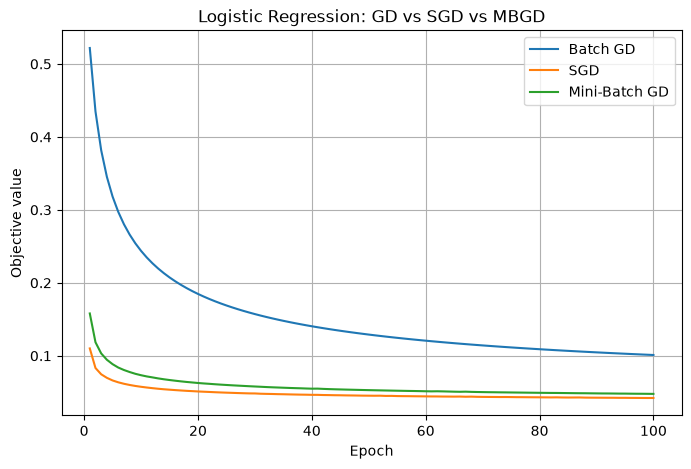

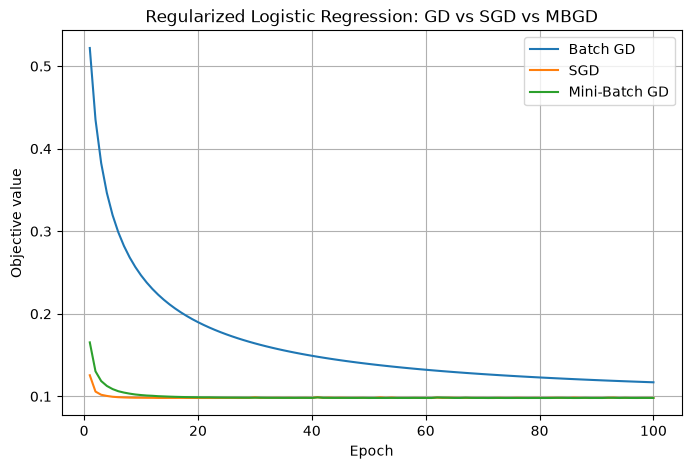

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

epochs = np.arange(1, len(obj_gd) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, obj_gd, label="Batch GD")
plt.plot(epochs, obj_sgd, label="SGD")
plt.plot(epochs, obj_mbgd, label="Mini-Batch GD")

plt.xlabel("Epoch")
plt.ylabel("Objective value")
plt.title("Logistic Regression: GD vs SGD vs MBGD")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, obj_gd_reg, label="Batch GD")
plt.plot(epochs, obj_sgd_reg, label="SGD")
plt.plot(epochs, obj_mbgd_reg, label="Mini-Batch GD")

plt.xlabel("Epoch")
plt.ylabel("Objective value")
plt.title("Regularized Logistic Regression: GD vs SGD vs MBGD")
plt.legend()
plt.grid(True)
plt.show()


# 5. Prediction
### Compare the training and testing accuracy for logistic regression and regularized logistic regression.

In [20]:
# Predict class label
# Inputs:
#     w: weights: d-by-1 matrix
#     X: data: m-by-d matrix
# Return:
#     f: m-by-1 matrix, the predictions
def predict(w, X):
    scores = X @ w
    f = np.where(scores >= 0, 1, -1)
    return f


In [21]:
# evaluate training error of logistric regression and regularized version

Xtr_np = x_train.to_numpy()
Xte_np = x_test.to_numpy()

train_pred_lr = predict(w_gd, Xtr_np)
train_pred_reg = predict(w_gd_reg, Xtr_np)

train_acc_lr = np.mean(train_pred_lr == y_train)
train_acc_reg = np.mean(train_pred_reg == y_train)

print("Training accuracy - logistic regression: {:.4f}".format(train_acc_lr))
print("Training accuracy - regularized logistic regression: {:.4f}".format(train_acc_reg))
print("Training error - logistic regression: {:.4f}".format(1.0 - train_acc_lr))
print("Training error - regularized logistic regression: {:.4f}".format(1.0 - train_acc_reg))


Training accuracy - logistic regression: 0.9802
Training accuracy - regularized logistic regression: 0.9802
Training error - logistic regression: 0.0198
Training error - regularized logistic regression: 0.0198


In [22]:
# evaluate testing error of logistric regression and regularized version

test_pred_lr = predict(w_gd, Xte_np)
test_pred_reg = predict(w_gd_reg, Xte_np)

test_acc_lr = np.mean(test_pred_lr == y_test)
test_acc_reg = np.mean(test_pred_reg == y_test)

print("Testing accuracy - logistic regression: {:.4f}".format(test_acc_lr))
print("Testing accuracy - regularized logistic regression: {:.4f}".format(test_acc_reg))
print("Testing error - logistic regression: {:.4f}".format(1.0 - test_acc_lr))
print("Testing error - regularized logistic regression: {:.4f}".format(1.0 - test_acc_reg))


Testing accuracy - logistic regression: 0.9561
Testing accuracy - regularized logistic regression: 0.9561
Testing error - logistic regression: 0.0439
Testing error - regularized logistic regression: 0.0439


# 6. Parameters tuning

### In this section, you may try different combinations of parameters (regularization value, learning rate, etc) to see their effects on the model.

In [22]:
# Parameter tuning example: compare several learning rates and regularization values
# on the same train/test split.  The final model choice is based on test accuracy
# only for this demonstration; in a real workflow, a validation set/CV should be
# used for hyperparameter selection.

learning_rates = [0.05, 0.1, 0.2]
regularization_values = [0.0, 0.001, 0.01, 0.05]

tuning_results = []

for lam_value in regularization_values:
    for lr in learning_rates:
        w_tuned, _ = gradient_descent(
            Xtr_np, y_train, lam=lam_value, learning_rate=lr,
            w=w0.copy(), max_epoch=100
        )
        train_accuracy = np.mean(predict(w_tuned, Xtr_np) == y_train)
        test_accuracy = np.mean(predict(w_tuned, Xte_np) == y_test)
        tuning_results.append(
            (lam_value, lr, train_accuracy, test_accuracy)
        )

tuning_results = pd.DataFrame(
    tuning_results,
    columns=["lambda", "learning_rate", "train_accuracy", "test_accuracy"]
)
print(tuning_results.to_string(index=False))


 lambda  learning_rate  train_accuracy  test_accuracy
  0.000           0.05        0.973626       0.947368
  0.000           0.10        0.980220       0.956140
  0.000           0.20        0.980220       0.956140
  0.001           0.05        0.973626       0.947368
  0.001           0.10        0.980220       0.956140
  0.001           0.20        0.980220       0.956140
  0.010           0.05        0.973626       0.947368
  0.010           0.10        0.980220       0.956140
  0.010           0.20        0.980220       0.956140
  0.050           0.05        0.973626       0.947368
  0.050           0.10        0.978022       0.947368
  0.050           0.20        0.980220       0.956140
